# 03 — Feature Engineering

**Project**: [Flu Shot Learning: Predict H1N1 and Seasonal Flu Vaccines](https://www.drivendata.org/competitions/66/flu-shot-learning/)

**Author**: Jarret Angbazo

**Date**: May 2026

**Purpose**: Engineer new features from the cleaned data produced by `02_data_cleaning.ipynb`, guided directly by EDA findings. Outputs the final feature matrices for `04_modeling.ipynb`.

---

## Table of Contents

1. [Setup & Load](#1-setup--load)
2. [MNAR Signal Features](#2-mnar-signal-features)
   - [2.1 `missing_opinion_count`](#21-missing_opinion_count)
3. [Domain Features](#3-domain-features)
   - [3.1 `high_vacc_ind_occ`](#31-high_vacc_ind_occ)
   - [3.2 `doctor_recc_both`](#32-doctor_recc_both)
4. [Composite / Aggregation Features](#4-composite--aggregation-features)
   - [4.1 `opinion_h1n1_composite`](#41-opinion_h1n1_composite)
   - [4.2 `opinion_seas_composite`](#42-opinion_seas_composite)
   - [4.3 `behavior_composite`](#43-behavior_composite)
5. [Feature Selection — Drop Low-Signal Columns](#5-feature-selection--drop-low-signal-columns)
6. [Multicollinearity Check](#6-multicollinearity-check)
7. [Final Shape & Column Inventory](#7-final-shape--column-inventory)
8. [Save Engineered Features](#8-save-engineered-features)
9. [Feature Engineering Summary](#9-feature-engineering-summary)

---

## 1. Setup & Load <a id='1-setup--load'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Settings
pd.set_option('display.max_columns', None)

# Warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Define paths and constants
from graphene import ID


PROCESSED_PATH         = Path('../data/processed')
FIGURES                = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

TARGET_COLS     = ['h1n1_vaccine', 'seasonal_vaccine']
ID_COL          = 'respondent_id'

# Load cleaned data
X_train  = pd.read_csv(PROCESSED_PATH / 'X_train_clean.csv', index_col = ID_COL)
X_test   = pd.read_csv(PROCESSED_PATH / 'X_test_clean.csv',  index_col = ID_COL)
y_train  = pd.read_csv(PROCESSED_PATH / 'y_train.csv',       index_col = ID_COL)

# We also need the RAW features to compute opinion missingness counts 
RAW_PATH  = Path('../data/raw')
raw_train = pd.read_csv(RAW_PATH / 'training_set_features.csv', index_col = ID_COL)
raw_test  = pd.read_csv(RAW_PATH / 'test_set_features.csv',     index_col = ID_COL)

print("Loaded succesfully.")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")

Loaded succesfully.
X_train : (26707, 56)
X_test  : (26708, 56)
y_train : (26707, 2)


## 2. MNAR Signal Features <a id='2-mnar-signal-features'></a>

**EDA finding (Section 5.3):** Opinion column missingness is MNAR for the seasonal target.
Respondents who skip opinion questions have 7.6–10.3 percentage points lower seasonal vaccination
rates. The missingness pattern is itself a predictive signal.

`missing_opinion_count` is computed from the **raw** data (pre-imputation) because imputation in
`02_data_cleaning.ipynb` already filled in those values.

### 2.1 `missing_opinion_count` <a id='21-missing_opinion_count'></a>

In [3]:
OPINION_COLS = [
    'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk',
    'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective',
    'opinion_seas_risk',
    'opinion_seas_sick_from_vacc',
]

X_train['missing_opinion_count'] = raw_train[OPINION_COLS].isnull().sum(axis=1).astype('int8')
X_test['missing_opinion_count']  = raw_test[OPINION_COLS].isnull().sum(axis=1).astype('int8')

print("missing_opinion_count distribution (train):")
print(X_train['missing_opinion_count'].value_counts().sort_index().to_string())

# Sanity check: rows with high missing_opinion_count should have lower vaccination rates
print("\nSeasonal vaccination rate by missing_opinion_count:")
check = pd.concat([X_train[['missing_opinion_count']], y_train], axis=1)
print(check.groupby('missing_opinion_count')['seasonal_vaccine'].mean().round(3).to_string())

missing_opinion_count distribution (train):
missing_opinion_count
0    26002
1      171
2      101
3       47
4       49
5       45
6      292

Seasonal vaccination rate by missing_opinion_count:
missing_opinion_count
0    0.468
1    0.415
2    0.347
3    0.447
4    0.388
5    0.489
6    0.356


## 3. Domain Features <a id='3-domain-features'></a>

Two features grounded directly in EDA findings about specific high-signal categorical codes.

### 3.1 `high_vacc_ind_occ` <a id='31-high_vacc_ind_occ'></a>

**EDA finding (Section 6):** Two obfuscated category codes have the highest vaccination rates
in their respective columns:
- `employment_industry == 'haxffmxo'`: 62.2% h1n1, 84.5% seasonal vaccination rate
- `employment_occupation == 'dcjcmpih'`: 62.2% h1n1, 84.6% seasonal vaccination rate

Both are substantially above the dataset-wide rates (21.2% h1n1, 46.6% seasonal).
These codes are treated as opaque — no external interpretation is applied.
The raw categorical values were target-encoded in `02_data_cleaning.ipynb`, so this flag is
computed from the **raw** data before encoding consumed the original string values.

In [4]:
# Codes with highest vaccination rates in EDA (treated as opaque — no external label applied)
TOP_IND_CODE = 'haxffmxo'
TOP_OCC_CODE = 'dcjcmpih'

is_top_train = (
    (raw_train['employment_industry']  == TOP_IND_CODE) |
    (raw_train['employment_occupation'] == TOP_OCC_CODE)
).astype('int8')

is_top_test = (
    (raw_test['employment_industry']  == TOP_IND_CODE) |
    (raw_test['employment_occupation'] == TOP_OCC_CODE)
).astype('int8')

X_train['high_vacc_ind_occ'] = is_top_train.values
X_test['high_vacc_ind_occ']  = is_top_test.values

print('high_vacc_ind_occ distribution (train):')
print(X_train['high_vacc_ind_occ'].value_counts().to_dict())

# Validate signal
check = pd.concat([X_train[['high_vacc_ind_occ']], y_train], axis=1)
print('\nVaccination rates by high_vacc_ind_occ:')
print(check.groupby('high_vacc_ind_occ')[TARGET_COLS].mean().round(3))

high_vacc_ind_occ distribution (train):
{0: 26559, 1: 148}

Vaccination rates by high_vacc_ind_occ:
                   h1n1_vaccine  seasonal_vaccine
high_vacc_ind_occ                                
0                         0.210             0.463
1                         0.622             0.845


### 3.2 `doctor_recc_both` <a id='32-doctor_recc_both'></a>

**EDA finding (Section 8):** `doctor_recc_h1n1` (r = 0.394) and `doctor_recc_seasonal` (r = 0.369)
are the single strongest numeric predictors of their respective targets, and they carry cross-target
signal at r ≈ 0.20. A respondent who received both recommendations is the strongest possible
physician-influence case — this interaction captures a ceiling effect not visible in either feature alone.

In [5]:
X_train['doctor_recc_both'] = (
    (X_train['doctor_recc_h1n1'] == 1) & (X_train['doctor_recc_seasonal'] == 1)
).astype('int8')

X_test['doctor_recc_both'] = (
    (X_test['doctor_recc_h1n1'] == 1) & (X_test['doctor_recc_seasonal'] == 1)
).astype('int8')

print("doctor_recc_both distribution (train):")
print(X_train['doctor_recc_both'].value_counts().to_dict())

check = pd.concat([X_train[['doctor_recc_both']], y_train], axis=1)
print("\nVaccination rates by doctor_recc_both:")
print(check.groupby('doctor_recc_both')[TARGET_COLS].mean().round(3))

doctor_recc_both distribution (train):
{0: 22093, 1: 4614}

Vaccination rates by doctor_recc_both:
                  h1n1_vaccine  seasonal_vaccine
doctor_recc_both                                
0                        0.144             0.413
1                        0.541             0.715


## 4. Composite / Aggregation Features <a id='4-composite--aggregation-features'></a>

**EDA finding (Section 8):** Opinion features within each target domain are moderately correlated
with each other and individually correlated with both targets. Composites reduce dimensionality
while preserving the signal cluster. Behavioral features are individually weak (r < 0.12) but may
aggregate meaningful signal.

All composites are computed on the **already-imputed** values from `X_train_clean.csv`.

### 4.1 `opinion_h1n1_composite` <a id='41-opinion_h1n1_composite'></a>

In [6]:
H1N1_OPINION_COLS = [
    'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk',
    'opinion_h1n1_sick_from_vacc',
]

X_train['opinion_h1n1_composite'] = X_train[H1N1_OPINION_COLS].mean(axis=1)
X_test['opinion_h1n1_composite']  = X_test[H1N1_OPINION_COLS].mean(axis=1)

print(f"opinion_h1n1_composite — train stats:")
print(X_train['opinion_h1n1_composite'].describe().round(3))

# Correlation with h1n1_vaccine
r = pd.concat([X_train[['opinion_h1n1_composite']], y_train['h1n1_vaccine']], axis=1).corr()
print(f"\nCorrelation with h1n1_vaccine: {r.loc['opinion_h1n1_composite','h1n1_vaccine']:.3f}")

opinion_h1n1_composite — train stats:
count    26707.000
mean         2.848
std          0.847
min          1.000
25%          2.333
50%          2.667
75%          3.333
max          5.000
Name: opinion_h1n1_composite, dtype: float64

Correlation with h1n1_vaccine: 0.306


### 4.2 `opinion_seas_composite` <a id='42-opinion_seas_composite'></a>

In [7]:
SEAS_OPINION_COLS = [
    'opinion_seas_vacc_effective',
    'opinion_seas_risk',
    'opinion_seas_sick_from_vacc',
]

X_train['opinion_seas_composite'] = X_train[SEAS_OPINION_COLS].mean(axis=1)
X_test['opinion_seas_composite']  = X_test[SEAS_OPINION_COLS].mean(axis=1)

print(f"opinion_seas_composite — train stats:")
print(X_train['opinion_seas_composite'].describe().round(3))

r = pd.concat([X_train[['opinion_seas_composite']], y_train['seasonal_vaccine']], axis=1).corr()
print(f"\nCorrelation with seasonal_vaccine: {r.loc['opinion_seas_composite','seasonal_vaccine']:.3f}")

opinion_seas_composite — train stats:
count    26707.000
mean         2.949
std          0.849
min          1.000
25%          2.333
50%          3.000
75%          3.333
max          5.000
Name: opinion_seas_composite, dtype: float64

Correlation with seasonal_vaccine: 0.329


### 4.3 `behavior_composite` <a id='43-behavior_composite'></a>

In [8]:
# EDA note: behavioral_large_gatherings and behavioral_outside_home are r=0.584 with each other
# and both weakly predictive. Including all 7 behavioral features in the composite; the modeling
# notebook can test with/without individual features vs. composite.
BEHAVIORAL_COLS = [
    'behavioral_antiviral_meds',
    'behavioral_avoidance',
    'behavioral_face_mask',
    'behavioral_wash_hands',
    'behavioral_large_gatherings',
    'behavioral_outside_home',
    'behavioral_touch_face',
]

X_train['behavior_composite'] = X_train[BEHAVIORAL_COLS].mean(axis=1)
X_test['behavior_composite']  = X_test[BEHAVIORAL_COLS].mean(axis=1)

print(f"behavior_composite — train stats:")
print(X_train['behavior_composite'].describe().round(3))

for t in TARGET_COLS:
    r = pd.concat([X_train[['behavior_composite']], y_train[t]], axis=1).corr()
    print(f"Correlation with {t}: {r.loc['behavior_composite', t]:.3f}")

behavior_composite — train stats:
count    26707.000
mean         0.435
std          0.228
min          0.000
25%          0.286
50%          0.429
75%          0.571
max          1.000
Name: behavior_composite, dtype: float64
Correlation with h1n1_vaccine: 0.080
Correlation with seasonal_vaccine: 0.126


## 5. Feature Selection — Drop Low-Signal Columns <a id='5-feature-selection--drop-low-signal-columns'></a>

**EDA finding:** `census_msa` shows near-zero rate variation across its 3 categories (< 2 pp spread
for both targets). After one-hot encoding it contributed 3 columns with no predictive value.

> All other columns are retained at this stage. Permutation importance in `04_modeling.ipynb`
> will surface any additional low-value features after the model has been fit.

In [9]:
# Drop census_msa one-hot columns (all three levels)
census_msa_cols = [c for c in X_train.columns if c.startswith('census_msa_')]

X_train.drop(columns=census_msa_cols, inplace=True)
X_test.drop( columns=census_msa_cols, inplace=True)

print(f"Dropped low-signal columns: {census_msa_cols}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

Dropped low-signal columns: ['census_msa_MSA, Not Principle  City', 'census_msa_MSA, Principle City', 'census_msa_Non-MSA']

X_train shape: (26707, 59)
X_test  shape: (26708, 59)


## 6. Multicollinearity Check <a id='6-multicollinearity-check'></a>

**EDA finding:** `behavioral_large_gatherings` and `behavioral_outside_home` had r = 0.584 — the
highest pair-wise correlation in the numeric feature set. Flag any pairs above 0.80 post-engineering
as candidates for removal before linear models (tree models tolerate this).

In [10]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
corr_matrix = X_train[num_cols].corr().abs()

# Extract upper triangle only
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
    .query('abs_corr >= 0.80')
    .sort_values('abs_corr', ascending=False)
)

if high_corr.empty:
    print("No numeric feature pairs with |r| >= 0.80 found.")
    print("Note: behavioral_large_gatherings / behavioral_outside_home (r=0.584) is below threshold.")
    print("Both are retained; review permutation importance before linear models.")
else:
    print("High-correlation pairs (|r| >= 0.80):")
    print(high_corr.to_string(index=False))
    print("\nConsider dropping one from each pair before training linear/distance-based models.")

High-correlation pairs (|r| >= 0.80):
                            feature_1                                 feature_2  abs_corr
        employment_occupation_missing               employment_industry_missing  0.972945
                     doctor_recc_h1n1                          doctor_recc_both  0.906928
  employment_industry_te_h1n1_vaccine   employment_industry_te_seasonal_vaccine  0.880251
employment_occupation_te_h1n1_vaccine employment_occupation_te_seasonal_vaccine  0.834135
                    employment_status               employment_industry_missing  0.822702
                    employment_status             employment_occupation_missing  0.814122

Consider dropping one from each pair before training linear/distance-based models.


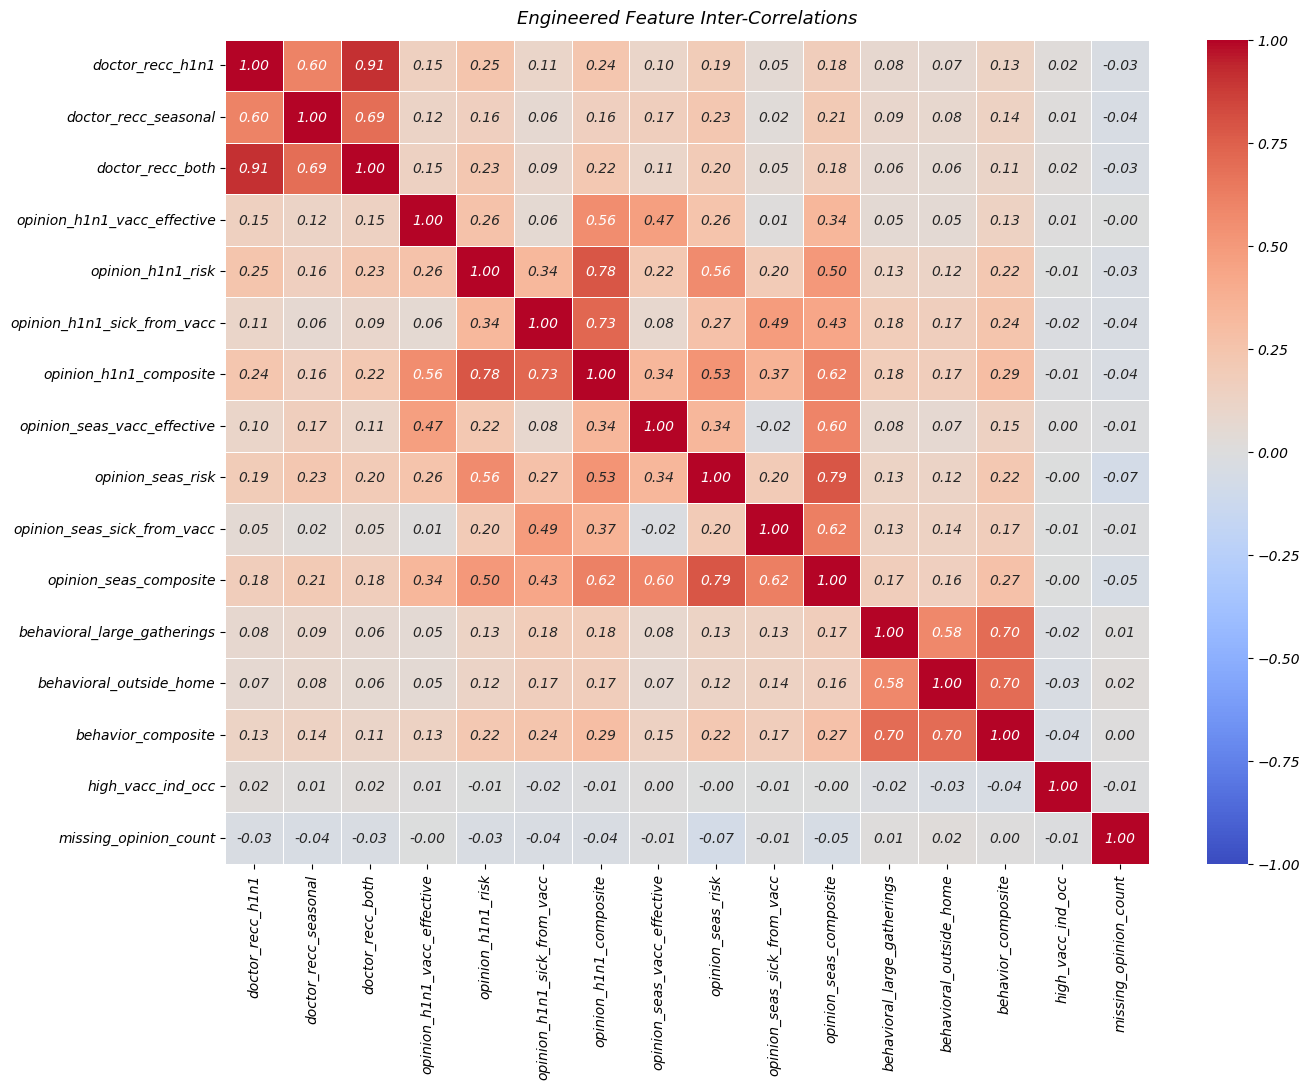

In [11]:
# Visual confirmation — correlation heatmap of engineered + original numeric features
# Limit to columns of primary interest for readability
key_cols = [
    'doctor_recc_h1n1', 'doctor_recc_seasonal', 'doctor_recc_both',
    'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_h1n1_composite',
    'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc',
    'opinion_seas_composite',
    'behavioral_large_gatherings', 'behavioral_outside_home', 'behavior_composite',
    'high_vacc_ind_occ', 'missing_opinion_count',
]
key_cols = [c for c in key_cols if c in X_train.columns]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    X_train[key_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax
)
ax.set_title('Engineered Feature Inter-Correlations', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(FIGURES / 'fe_01_correlation_heatmap.png', dpi=150)
plt.show()

## 7. Final Shape & Column Inventory <a id='7-final-shape--column-inventory'></a>

In [12]:
print(f"Final X_train shape : {X_train.shape}")
print(f"Final X_test  shape : {X_test.shape}")

print("\n--- All columns ---")
for i, col in enumerate(X_train.columns, 1):
    dtype = X_train[col].dtype
    print(f"  {i:02d}. {col:45s} {dtype}")

Final X_train shape : (26707, 59)
Final X_test  shape : (26708, 59)

--- All columns ---
  01. h1n1_concern                                  int64
  02. h1n1_knowledge                                int64
  03. behavioral_antiviral_meds                     int64
  04. behavioral_avoidance                          int64
  05. behavioral_face_mask                          int64
  06. behavioral_wash_hands                         int64
  07. behavioral_large_gatherings                   int64
  08. behavioral_outside_home                       int64
  09. behavioral_touch_face                         int64
  10. doctor_recc_h1n1                              int64
  11. doctor_recc_seasonal                          int64
  12. chronic_med_condition                         int64
  13. child_under_6_months                          int64
  14. health_worker                                 int64
  15. health_insurance                              int64
  16. opinion_h1n1_vacc_effective        

In [13]:
# Quick correlation summary: all features vs both targets
combined = pd.concat([X_train, y_train], axis=1)
print("\nTop 15 features by |correlation| with h1n1_vaccine:")
corr_h1n1 = combined.corr()['h1n1_vaccine'].drop(TARGET_COLS).abs().sort_values(ascending=False)
print(corr_h1n1.head(15).round(3).to_string())

print("\nTop 15 features by |correlation| with seasonal_vaccine:")
corr_seas = combined.corr()['seasonal_vaccine'].drop(TARGET_COLS).abs().sort_values(ascending=False)
print(corr_seas.head(15).round(3).to_string())


Top 15 features by |correlation| with h1n1_vaccine:
doctor_recc_h1n1                             0.394
doctor_recc_both                             0.367
opinion_h1n1_risk                            0.321
opinion_h1n1_composite                       0.306
opinion_h1n1_vacc_effective                  0.267
opinion_seas_risk                            0.256
health_insurance_missing                     0.225
doctor_recc_seasonal                         0.219
opinion_seas_composite                       0.218
employment_occupation_te_h1n1_vaccine        0.179
opinion_seas_vacc_effective                  0.178
health_worker                                0.168
employment_occupation_te_seasonal_vaccine    0.151
employment_industry_te_h1n1_vaccine          0.125
h1n1_concern                                 0.122

Top 15 features by |correlation| with seasonal_vaccine:
opinion_seas_risk                            0.387
doctor_recc_seasonal                         0.361
opinion_seas_vacc_effec

## 8. Save Engineered Features <a id='8-save-engineered-features'></a>

In [14]:
X_train.to_csv(PROCESSED_PATH / 'X_train_features.csv')
X_test.to_csv( PROCESSED_PATH / 'X_test_features.csv')
# y_train is unchanged — no need to re-save, but keeping for completeness
y_train.to_csv(PROCESSED_PATH / 'y_train.csv')

print("Saved:")
print(f"  X_train_features.csv  {X_train.shape}")
print(f"  X_test_features.csv   {X_test.shape}")
print(f"  y_train.csv           {y_train.shape}")

Saved:
  X_train_features.csv  (26707, 59)
  X_test_features.csv   (26708, 59)
  y_train.csv           (26707, 2)


## 9. Feature Engineering Summary <a id='9-feature-engineering-summary'></a>

### Features Created

| Feature | Type | EDA basis | Signal |
|---|---|---|---|
| `missing_opinion_count` | int8, 0–6 | MNAR confirmed: 7.6–10.3 pp seasonal rate diff when opinion missing | Captures non-response signal; respondents with missing opinions have lower vaccination rates |
| `high_vacc_ind_occ` | int8, 0/1 | Industry code 'haxffmxo' / Occupation code 'dcjcmpih' = 62% h1n1, 84% seasonal vacc rate — highest of any code | Strongest categorical signal in the dataset |
| `doctor_recc_both` | int8, 0/1 | Both doctor recc features are top-2 numeric predictors | Captures ceiling of physician influence |
| `opinion_h1n1_composite` | float | Three h1n1 opinion features individually correlated at 0.27–0.32 with h1n1_vaccine | Aggregates correlated opinion cluster |
| `opinion_seas_composite` | float | Three seasonal opinion features individually correlated at 0.36–0.39 with seasonal_vaccine | Aggregates correlated opinion cluster |
| `behavior_composite` | float | All 7 behavioral features individually weak (r < 0.12) | May surface aggregate behavioral signal |

### Features Dropped

| Feature | Reason |
|---|---|
| `census_msa_*` (3 columns) | < 2 pp vaccination rate spread across all 3 categories — no signal |

### Modeling Notes for `04_modeling.ipynb`

- **LightGBM**: use `X_train_features.csv` directly. No scaling. Native missing not needed
  (all NaNs resolved in `02_data_cleaning.ipynb`). `scale_pos_weight = 3.71` for h1n1 model only.
- **Logistic regression baseline**: StandardScaler required. Drop composite columns that overlap
  with their component features (avoid multicollinearity inflation). Use `class_weight='balanced'`
  for h1n1.
- **Evaluation**: ROC-AUC averaged across both targets (DrivenData metric). Use stratified 5-fold
  CV stratified on `h1n1_vaccine` (minority class).
- **Permutation importance**: after first LightGBM fit, check `behavioral_outside_home` vs.
  `behavior_composite` to decide whether to drop the redundant behavioral pair.
- **Feature set variants to compare**:
  1. Original cleaned features only (no composites, no engineered)
  2. + MNAR indicators + `high_vacc_ind_occ` + `doctor_recc_both`
  3. + composites